# Phân tích và dự đoán xu hướng tuyển dụng IT tại Việt Nam

Notebook ưu tiên dữ liệu đã feature engineering tại `data/features/jobs_featured_full.csv`. Nếu file này chưa có, notebook mới lần lượt dùng `jobs_raw.csv` hoặc `data/processed/jobs_cleaned_full.csv`. Chạy các cell theo thứ tự từ trên xuống.

In [3]:
from pathlib import Path
import json
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
ARTIFACT_DIR = PROJECT_ROOT / 'reports' / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
print(f'Project root: {PROJECT_ROOT}')

Project root: D:\GITHUB\job_prediction


## 1. Load dataset

In [4]:
def find_dataset(root: Path) -> Path:
    candidates = [root / 'data' / 'features' / 'jobs_featured_full.csv',
                  root / 'jobs_raw.csv', root / 'data' / 'raw' / 'jobs_raw.csv',
                  root / 'data' / 'processed' / 'jobs_cleaned_full.csv']
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError('Không tìm thấy jobs_featured_full.csv, jobs_raw.csv hoặc jobs_cleaned_full.csv.')

DATA_PATH = find_dataset(PROJECT_ROOT)
raw = pd.read_csv(DATA_PATH)
# jobs_featured_full.csv chứa các cột đã được feature engineering; giữ lại chúng khi tiền xử lý.
IS_FEATURED_DATA = 'skill_count' in raw.columns
# Lưu danh sách cột skill của file đầu vào trước khi notebook tạo thêm các cột skill_* riêng.
INPUT_FEATURED_SKILL_COLUMNS = [col for col in raw.columns
                               if col.startswith('skill_') and col != 'skill_count'
                               and set(pd.to_numeric(raw[col], errors='coerce').dropna().unique()).issubset({0, 1})]
# Ánh xạ schema crawler/ETL về schema chuẩn của notebook.
ALIASES = {'job_title': 'title', 'company_name': 'company', 'salary_min': 'salary_min_vnd',
           'salary_max': 'salary_max_vnd', 'experience_required': 'experience', 'skills': 'skills_existing',
           'job_description': 'description'}
raw = raw.rename(columns={old: new for old, new in ALIASES.items() if old in raw.columns and new not in raw.columns})
required = {'title', 'location'}
missing = required - set(raw.columns)
if missing:
    raise ValueError(f'Thiếu cột bắt buộc: {sorted(missing)}. Cần tối thiểu title và location.')
for col in ['company', 'salary', 'salary_min_vnd', 'salary_max_vnd', 'experience', 'job_level', 'description', 'posted_date', 'source', 'skills_existing']:
    if col not in raw.columns:
        raw[col] = np.nan
print(f'Loaded {DATA_PATH.relative_to(PROJECT_ROOT)}: {raw.shape[0]:,} rows × {raw.shape[1]} columns')
print(f'Feature-engineered input: {IS_FEATURED_DATA}')
display(raw.head())
display(raw.isna().sum().sort_values(ascending=False).to_frame('missing_values'))

Loaded data\features\jobs_featured_full.csv: 6,301 rows × 82 columns
Feature-engineered input: True


,title,company,location,posted_date,salary_min_vnd,salary_max_vnd,salary_currency,job_type,job_level,experience,...,cat_Game,cat_DataEngineer,cat_Consultant,cat_Embedded,cat_Cloud,cat_Architect,cat_DBA,cat_Blockchain,salary,description
0,IT Manager,CÔNG TY CỔ PHẦN THẮNG LỢI HOMES,Other,2026-06-21,NaN,NaN,NaN,Full-time,Manager+,2.0,...,0,0,0,0,0,0,0,0,NaN,NaN
1,Other,CÔNG TY TNHH GIẢI PHÁP NHÀ MÁY THÔNG MINH VIỆT...,Hanoi,2026-06-21,NaN,NaN,NaN,Full-time,Fresher,0.0,...,0,0,0,0,0,0,0,0,NaN,NaN
2,UI/UX Designer,CÔNG TY CỔ PHẦN ĐẦU TƯ CÔNG NGHỆ VÀ THƯƠNG MẠI...,Hanoi,2026-06-21,NaN,NaN,NaN,Full-time,Junior,1.0,...,0,0,0,0,0,0,0,0,NaN,NaN
3,DevOps/Infra Engineer,Công ty Cổ phần Tập đoàn G,Hanoi,2026-06-21,NaN,NaN,NaN,Full-time,Mid,4.0,...,0,0,0,0,0,0,0,0,NaN,NaN
4,UI/UX Designer,CÔNG TY CỔ PHẦN TẬP ĐOÀN VIBULA,Ho Chi Minh City,2026-06-21,NaN,NaN,NaN,Full-time,Junior,1.0,...,0,0,0,0,0,0,0,0,NaN,NaN


,missing_values
salary,6301
description,6301
salary_avg,4200
salary_range,4200
salary_min_vnd,4147
...,...
cat_Embedded,0
cat_Architect,0
cat_Cloud,0
cat_Blockchain,0


## 2. Data cleaning

In [5]:
def clean_text(text):
    return '' if pd.isna(text) else re.sub(r'\s+', ' ', str(text)).strip()

def parse_salary_to_vnd(salary_text):
    """Return (min_vnd, max_vnd); supports USD, triệu/million, up to and negotiable."""
    text = clean_text(salary_text).lower().replace(',', '')
    if not text or any(x in text for x in ['negotiable', 'thỏa thuận', 'thoả thuận', 'competitive']):
        return (np.nan, np.nan)
    values = [float(x) for x in re.findall(r'\d+(?:\.\d+)?', text)]
    if not values:
        return (np.nan, np.nan)
    multiplier = 25_000_000 if 'usd' in text or '$' in text else (1_000_000 if any(x in text for x in ['triệu', 'trieu', 'million', 'm ']) else 1)
    values = [v * multiplier for v in values[:2]]
    if 'up to' in text or 'tối đa' in text:
        return (np.nan, values[0])
    return (values[0], values[-1]) if len(values) > 1 else (values[0], values[0])

def parse_experience(exp_text):
    text = clean_text(exp_text).lower()
    if any(x in text for x in ['intern', 'thực tập']): return 0.0
    if any(x in text for x in ['fresher', 'fresh graduate', 'new graduate']): return 0.5
    nums = [float(x) for x in re.findall(r'\d+(?:\.\d+)?', text)]
    return np.mean(nums[:2]) if nums else np.nan

def normalize_location(location):
    text = clean_text(location).lower()
    if any(x in text for x in ['hồ chí minh', 'ho chi minh', 'hcm', 'sài gòn', 'sai gon']): return 'Ho Chi Minh City'
    if any(x in text for x in ['hà nội', 'ha noi', 'hanoi']): return 'Hanoi'
    if any(x in text for x in ['đà nẵng', 'da nang']): return 'Da Nang'
    if 'remote' in text: return 'Remote'
    return 'Other'

def normalize_job_title(title):
    text = clean_text(title).lower()
    rules = [('Data Engineer', r'data engineer|etl|data pipeline'), ('AI/ML Engineer', r'\b(ai|ml)\b|machine learning|data scientist|nlp'),
             ('Data Analyst', r'data analyst|bi analyst|business intelligence'), ('DevOps/Infra Engineer', r'devops|sre|infrastructure'),
             ('Frontend Developer', r'front[ -]?end|react|angular|vue'), ('Backend Developer', r'back[ -]?end|java|\.net|php|node\.?js'),
             ('Mobile Developer', r'android|ios|flutter|react native'), ('QA/Tester', r'\bqa\b|tester|testing'),
             ('Project Manager', r'project manager|scrum master'), ('Business Analyst', r'business analyst'),
             ('Security Engineer', r'security|cyber'), ('Fullstack/Software Engineer', r'full[ -]?stack|software|developer|engineer')]
    return next((group for group, pattern in rules if re.search(pattern, text)), 'Other')

df = raw.copy()
# Chuẩn hoá kiểu dữ liệu trước; với file feature, salary/experience vốn đã là numeric.
for col in ['salary_min_vnd', 'salary_max_vnd', 'experience']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
parsed_salary = df['salary'].apply(parse_salary_to_vnd)
for i, col in enumerate(['salary_min_vnd', 'salary_max_vnd']):
    df[col] = df[col].fillna(parsed_salary.str[i])
computed_salary_avg = df[['salary_min_vnd', 'salary_max_vnd']].mean(axis=1)
if IS_FEATURED_DATA and 'salary_avg' in df.columns:
    df['salary_avg_vnd'] = pd.to_numeric(df['salary_avg'], errors='coerce').fillna(computed_salary_avg)
else:
    df['salary_avg_vnd'] = computed_salary_avg
if IS_FEATURED_DATA:
    # job_title trong file feature đã là category chuẩn; không map lại thành Other.
    df['experience_years'] = df['experience']
    df['job_title_group'] = df['title'].fillna('Other')
else:
    df['experience_years'] = df['experience'].apply(parse_experience)
    df['job_title_group'] = df['title'].apply(normalize_job_title)
df['location_norm'] = df['location'].apply(normalize_location)
df['description_clean'] = df['description'].apply(clean_text)
df['posted_date'] = pd.to_datetime(df['posted_date'], errors='coerce')
print(f"Invalid/missing posted_date: {df['posted_date'].isna().sum():,}")
display(df[['salary_min_vnd', 'salary_max_vnd', 'salary_avg_vnd', 'experience_years', 'location_norm', 'job_title_group']].head())

Invalid/missing posted_date: 70


,salary_min_vnd,salary_max_vnd,salary_avg_vnd,experience_years,location_norm,job_title_group
0,NaN,NaN,NaN,2.0,Other,IT Manager
1,NaN,NaN,NaN,0.0,Hanoi,Other
2,NaN,NaN,NaN,1.0,Hanoi,UI/UX Designer
3,NaN,NaN,NaN,4.0,Hanoi,DevOps/Infra Engineer
4,NaN,NaN,NaN,1.0,Ho Chi Minh City,UI/UX Designer


## 3. Skill extraction and multi-hot features

In [6]:
SKILLS = ['Python', 'Java', 'JavaScript', 'TypeScript', 'React', 'Vue', 'Angular', 'Node.js', 'Express', 'SQL', 'MySQL', 'PostgreSQL', 'MongoDB', 'Redis', 'Docker', 'Kubernetes', 'AWS', 'Azure', 'GCP', 'Linux', 'Git', 'CI/CD', 'Machine Learning', 'Deep Learning', 'NLP', 'Computer Vision', 'Data Analysis', 'Data Engineering', 'Spark', 'Hadoop', 'Airflow', 'Kafka', 'Power BI', 'Tableau', 'Excel', 'C++', 'C#', 'PHP', 'Laravel', 'Django', 'Flask', 'FastAPI', 'Spring Boot', 'Android', 'iOS', 'Flutter', 'DevOps', 'Security', 'Testing', 'QA', 'TensorFlow', 'PyTorch', 'Terraform', 'Jenkins', 'GraphQL', 'HTML', 'CSS', 'Go', 'Ruby', 'Scala', 'R', 'Selenium']
SKILL_PATTERNS = {skill: re.compile(r'(?<![\w+#.])' + re.escape(skill).replace(r'\ ', r'\s*') + r'(?![\w+#.])', re.I) for skill in SKILLS}
SKILL_PATTERNS.update({'Node.js': re.compile(r'\b(node\.?js|nodejs)\b', re.I), 'Vue': re.compile(r'\b(vue\.?js|vuejs|vue)\b', re.I), 'CI/CD': re.compile(r'\b(ci/cd|cicd)\b', re.I), 'C#': re.compile(r'c#|csharp', re.I), 'C++': re.compile(r'c\+\+|cpp', re.I)})
def extract_skills(description):
    text = clean_text(description)
    return [skill for skill, pattern in SKILL_PATTERNS.items() if pattern.search(text)]

def parse_existing_skills(value):
    # Dùng cùng pattern với description (Node.js, C++, C#, CI/CD...) để hai nguồn nhất quán.
    return extract_skills(value)

df['skills_extracted'] = df.apply(lambda row: extract_skills(row['description_clean']) or parse_existing_skills(row['skills_existing']), axis=1)
# Giữ skill_count đã được feature engineering nếu có; nó đếm toàn bộ skill trong dữ liệu gốc.
# skills_extracted vẫn dùng từ điển chuẩn 62 skill để phân tích trend và tạo các cột multi-hot.
if 'skill_count' in df.columns:
    df['num_skills'] = pd.to_numeric(df['skill_count'], errors='coerce').fillna(0).astype(int)
else:
    df['num_skills'] = df['skills_extracted'].str.len()
# Slug rõ nghĩa, bảo đảm duy nhất (đặc biệt C++ và C#).
SKILL_SLUGS = {'C++': 'c_plus_plus', 'C#': 'c_sharp'}
skill_columns = []
for skill in SKILLS:
    col = 'skill_' + SKILL_SLUGS.get(skill, re.sub(r'[^a-z0-9]+', '_', skill.lower()).strip('_'))
    df[col] = df['skills_extracted'].apply(lambda found, s=skill: int(s in found))
    skill_columns.append(col)
# Với jobs_featured_full.csv, skill trend phải dùng các cột nhị phân đã feature,
# không dùng skill_count (đây là số lượng skill của một tin, không phải một skill).
featured_skill_columns = [col for col in INPUT_FEATURED_SKILL_COLUMNS if col in df.columns]
featured_skill_labels = {
    col: col.removeprefix('skill_').replace('_', '/') if col == 'skill_CI_CD'
    else col.removeprefix('skill_').replace('_', ' ')
    for col in featured_skill_columns
}
trend_skill_columns = featured_skill_columns if IS_FEATURED_DATA and featured_skill_columns else skill_columns
trend_skill_labels = featured_skill_labels if IS_FEATURED_DATA and featured_skill_columns else {col: skill for skill, col in zip(SKILLS, skill_columns)}
print(f'{len(SKILLS)} skills configured; {df.skills_extracted.str.len().gt(0).sum():,} jobs contain recognised skills.')
print(f"{len(trend_skill_columns)} feature skill columns used for trend analysis: {', '.join(trend_skill_labels[col] for col in trend_skill_columns)}")
with open(ARTIFACT_DIR / 'skill_dictionary.json', 'w', encoding='utf-8') as f:
    json.dump({'skills': SKILLS}, f, ensure_ascii=False, indent=2)

62 skills configured; 2,861 jobs contain recognised skills.
20 feature skill columns used for trend analysis: AI, SQL, Java, API, Python, Excel, Agile, REST, Security, CI/CD, AWS, Linux, Docker, Scrum, ERP, DevOps, Git, React, CRM, JavaScript


## 4. Exploratory data analysis

,skill,job_count,zero_count
0,AI,1106,5195
1,SQL,732,5569
2,Python,633,5668
3,Java,600,5701
4,API,589,5712
5,Excel,566,5735
6,Agile,528,5773
7,Security,449,5852
8,REST,443,5858
9,AWS,387,5914


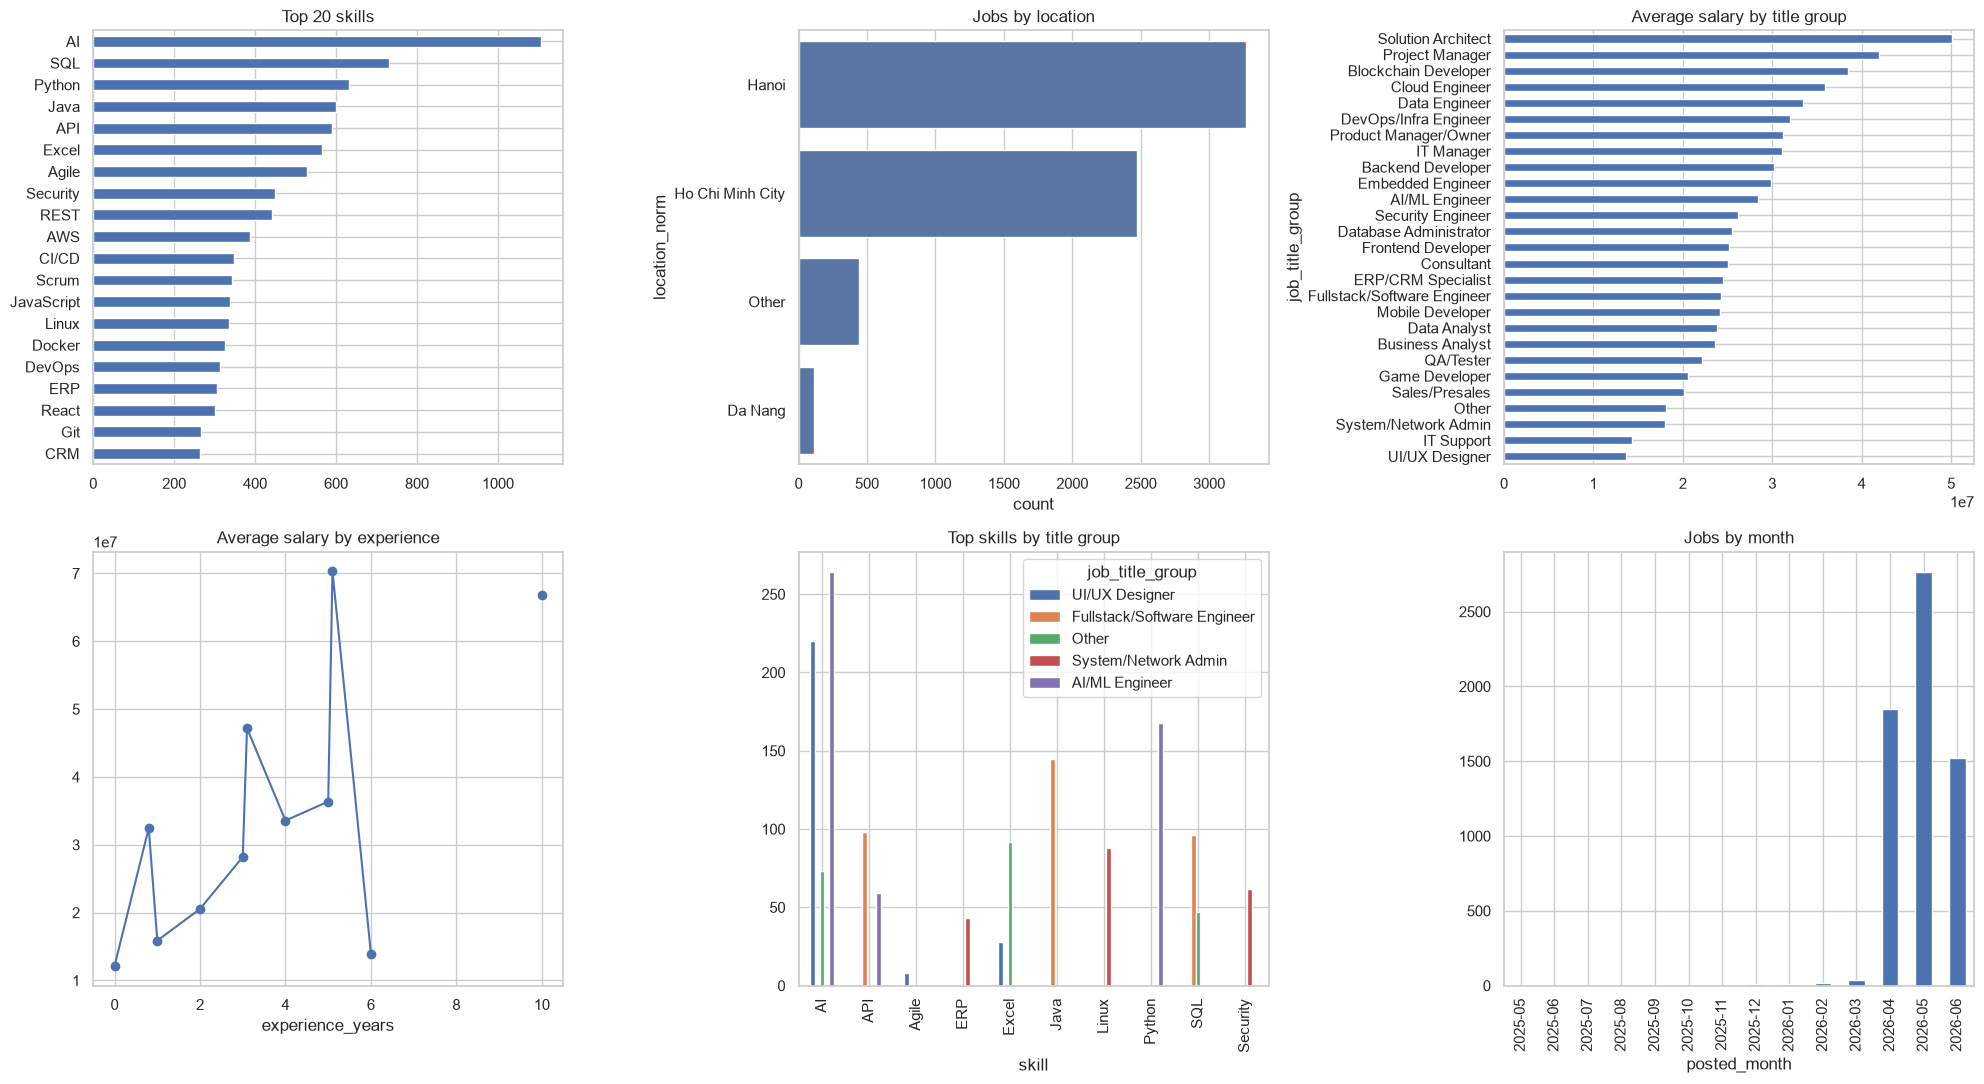

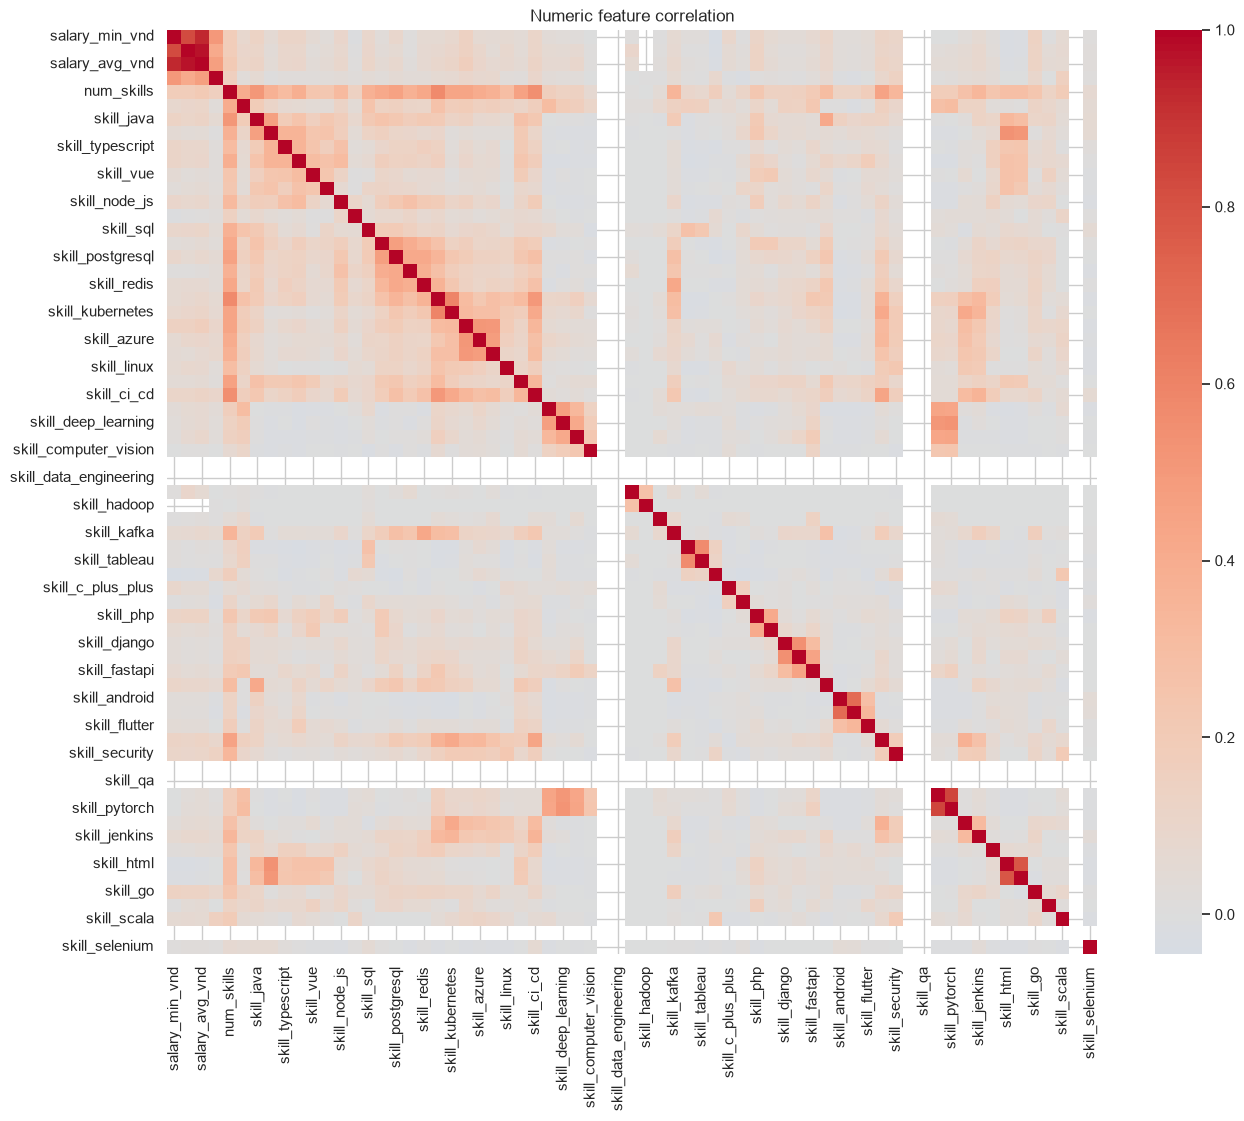

In [7]:
# Đếm trực tiếp từ các cột skill đã feature. Mỗi cột là cờ 0/1 nên tổng là số tin tuyển dụng yêu cầu skill đó.
trend_skill_counts = df[trend_skill_columns].apply(pd.to_numeric, errors='coerce').fillna(0).sum().sort_values(ascending=False)
# Gộp theo nhãn chuẩn để tránh hiển thị trùng nếu schema sau này có hai cột cùng một skill.
skill_counts = trend_skill_counts.rename(index=trend_skill_labels).groupby(level=0).sum().sort_values(ascending=False)
display(pd.DataFrame({'skill': skill_counts.index, 'job_count': skill_counts.values,
                      'zero_count': [int((pd.to_numeric(df[col], errors='coerce').fillna(0) == 0).sum()) for col in trend_skill_counts.index]}))
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
skill_counts.head(20).sort_values().plot.barh(ax=axes[0,0], title='Top 20 skills')
sns.countplot(data=df, y='location_norm', order=df['location_norm'].value_counts().index, ax=axes[0,1]); axes[0,1].set_title('Jobs by location')
df.groupby('job_title_group')['salary_avg_vnd'].mean().sort_values().plot.barh(ax=axes[0,2], title='Average salary by title group')
df.groupby('experience_years')['salary_avg_vnd'].mean().sort_index().plot(kind='line', marker='o', ax=axes[1,0], title='Average salary by experience')
top_groups = df['job_title_group'].value_counts().head(5).index
role_skill = df.melt(id_vars='job_title_group', value_vars=trend_skill_columns, var_name='skill_column', value_name='has_skill')
role_skill = role_skill[role_skill['has_skill'].eq(1)].assign(skill=lambda x: x['skill_column'].map(trend_skill_labels))
pd.crosstab(role_skill['job_title_group'], role_skill['skill']).reindex(top_groups).T.apply(lambda x: x.nlargest(3)).dropna(how='all').plot.bar(ax=axes[1,1], title='Top skills by title group')
df['posted_month'] = df['posted_date'].dt.to_period('M').astype(str).replace('NaT', np.nan)
df['posted_month'].value_counts().sort_index().plot.bar(ax=axes[1,2], title='Jobs by month')
plt.tight_layout(); plt.show()
numeric_cols = ['salary_min_vnd', 'salary_max_vnd', 'salary_avg_vnd', 'experience_years', 'num_skills'] + skill_columns
plt.figure(figsize=(15, 12)); sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', center=0); plt.title('Numeric feature correlation'); plt.show()

## 5. Salary prediction: training, evaluation and K-fold validation

,model,MAE,RMSE,R2
0,XGBoost,"7,709,371","13,886,473",0.326
1,Linear Regression,"8,154,521","14,047,809",0.310


5-fold CV — MAE: 7,268,349 ± 248,368; R²: 0.355 ± 0.019


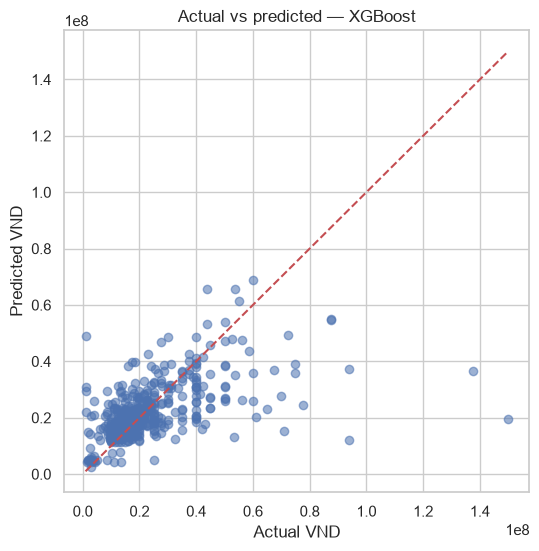

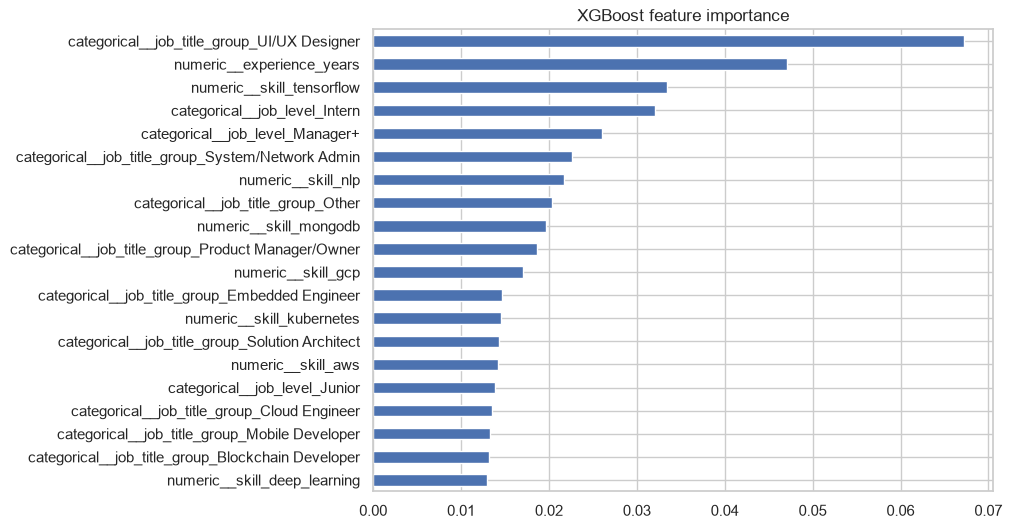

['D:\\GITHUB\\job_prediction\\reports\\artifacts\\feature_columns.pkl']

In [8]:
feature_cols = ['experience_years', 'num_skills', 'location_norm', 'job_level', 'job_title_group'] + skill_columns
model_df = df.dropna(subset=['salary_avg_vnd']).copy()
if len(model_df) < 30:
    raise ValueError(f'Cần ít nhất 30 dòng có salary_avg_vnd để train; hiện có {len(model_df)}.')
model_df['experience_years'] = model_df['experience_years'].fillna(model_df['experience_years'].median())
model_df['job_level'] = model_df['job_level'].fillna('Unknown').astype(str)
X, y = model_df[feature_cols], model_df['salary_avg_vnd']
cat_cols = ['location_norm', 'job_level', 'job_title_group']
num_cols = [c for c in feature_cols if c not in cat_cols]
preprocessor = ColumnTransformer([('categorical', OneHotEncoder(handle_unknown='ignore'), cat_cols), ('numeric', 'passthrough', num_cols)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
models = {'Linear Regression': LinearRegression(), 'XGBoost': XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, objective='reg:squarederror')}
pipelines, rows = {}, []
for name, estimator in models.items():
    pipe = Pipeline([('preprocessor', clone(preprocessor)), ('model', estimator)])
    pipe.fit(X_train, y_train); pred = pipe.predict(X_test); pipelines[name] = pipe
    rows.append({'model': name, 'MAE': mean_absolute_error(y_test, pred), 'RMSE': np.sqrt(mean_squared_error(y_test, pred)), 'R2': r2_score(y_test, pred)})
evaluation = pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)
best_name = evaluation.loc[0, 'model']; best_pipeline = pipelines[best_name]; best_pred = best_pipeline.predict(X_test)
display(evaluation.style.format({'MAE': '{:,.0f}', 'RMSE': '{:,.0f}', 'R2': '{:.3f}'}))
evaluation.to_csv(ARTIFACT_DIR / 'model_evaluation_report.csv', index=False)
cv = KFold(n_splits=min(5, len(model_df)), shuffle=True, random_state=RANDOM_STATE)
cv_result = cross_validate(best_pipeline, X, y, cv=cv, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})
print(f'5-fold CV — MAE: {-cv_result["test_mae"].mean():,.0f} ± {cv_result["test_mae"].std():,.0f}; R²: {cv_result["test_r2"].mean():.3f} ± {cv_result["test_r2"].std():.3f}')
plt.figure(figsize=(6, 6)); plt.scatter(y_test, best_pred, alpha=.55); lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]; plt.plot(lims, lims, 'r--'); plt.xlabel('Actual VND'); plt.ylabel('Predicted VND'); plt.title(f'Actual vs predicted — {best_name}'); plt.show()
if best_name == 'XGBoost':
    names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    importance = pd.Series(best_pipeline.named_steps['model'].feature_importances_, index=names).nlargest(20).sort_values()
    importance.plot.barh(figsize=(8, 6), title='XGBoost feature importance'); plt.show()
joblib.dump(best_pipeline, ARTIFACT_DIR / 'salary_prediction_model.pkl')
joblib.dump(best_pipeline.named_steps['preprocessor'], ARTIFACT_DIR / 'preprocessor.pkl')
joblib.dump(feature_cols, ARTIFACT_DIR / 'feature_columns.pkl')

## 6. Skill trend analysis on comparable months

Excluded 70 jobs and 100 skill observations with invalid/missing posted_date.
Eligible months (>= 500 jobs; latest incomplete month excluded): ['2026-04', '2026-05']


,skill,skill_column,posted_month,jobs_in_month,job_count,skill_share_pct
0,AI,skill_AI,2026-04,1851,358,19.340897
10,AI,skill_AI,2026-05,2763,534,19.326819
4,API,skill_API,2026-04,1851,202,10.913020
14,API,skill_API,2026-05,2763,280,10.133912
9,AWS,skill_AWS,2026-04,1851,112,6.050783
19,AWS,skill_AWS,2026-05,2763,183,6.623236
6,Agile,skill_Agile,2026-04,1851,163,8.806051
16,Agile,skill_Agile,2026-05,2763,262,9.482447
5,Excel,skill_Excel,2026-04,1851,181,9.778498
15,Excel,skill_Excel,2026-05,2763,269,9.735794


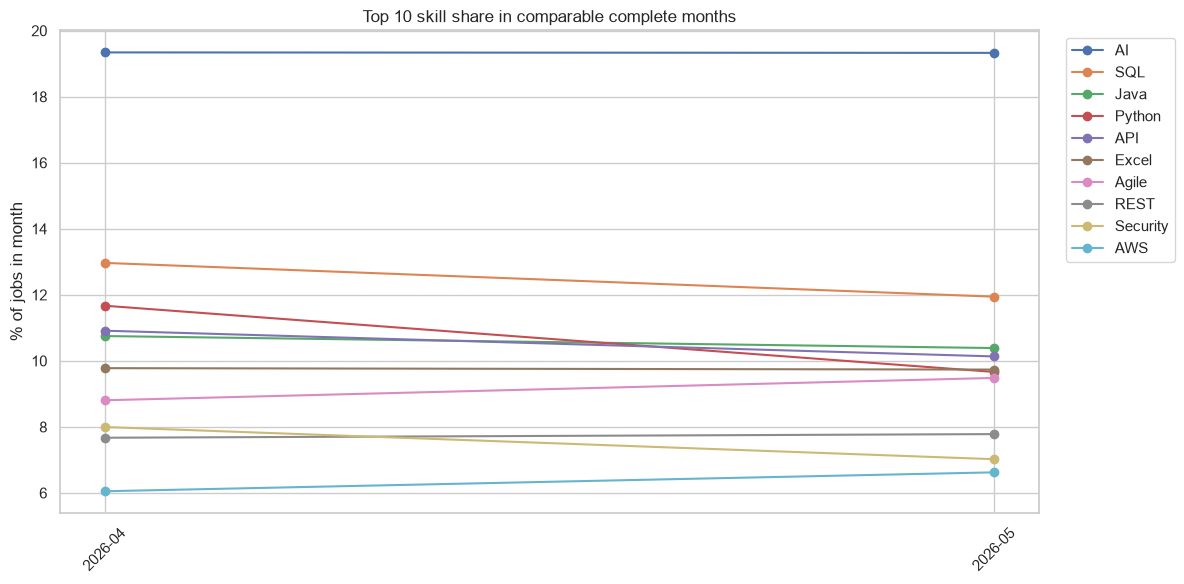

,skill,previous_month,current_month,previous_share_pct,current_share_pct,change_percentage_points
6,Agile,2026-04,2026-05,8.8%,9.5%,+0.7 pp
9,AWS,2026-04,2026-05,6.1%,6.6%,+0.6 pp
7,REST,2026-04,2026-05,7.7%,7.8%,+0.1 pp
0,AI,2026-04,2026-05,19.3%,19.3%,-0.0 pp
5,Excel,2026-04,2026-05,9.8%,9.7%,-0.0 pp
2,Java,2026-04,2026-05,10.8%,10.4%,-0.4 pp
4,API,2026-04,2026-05,10.9%,10.1%,-0.8 pp
8,Security,2026-04,2026-05,8.0%,7.0%,-1.0 pp
1,SQL,2026-04,2026-05,13.0%,11.9%,-1.0 pp
3,Python,2026-04,2026-05,11.7%,9.7%,-2.0 pp


,skill,input_months,current_month_count,current_month_share_pct,forecast_next_1_month_share_pct,expected_jobs_next_month,forecast_next_1_month,growth_rate,trend_label,data_quality_warning
0,AI,"2026-04, 2026-05, 2026-06",184,12.1%,9.7%,2307,224,+21.5%,Increasing,Experimental 3-month forecast; June is incomplete and estimated count assumes median April-May job volume.
1,SQL,"2026-04, 2026-05, 2026-06",141,9.3%,7.7%,2307,178,+26.1%,Increasing,Experimental 3-month forecast; June is incomplete and estimated count assumes median April-May job volume.
3,Python,"2026-04, 2026-05, 2026-06",136,8.9%,7.4%,2307,170,+25.0%,Increasing,Experimental 3-month forecast; June is incomplete and estimated count assumes median April-May job volume.
9,AWS,"2026-04, 2026-05, 2026-06",77,5.1%,4.9%,2307,114,+47.7%,Increasing,Experimental 3-month forecast; June is incomplete and estimated count assumes median April-May job volume.
2,Java,"2026-04, 2026-05, 2026-06",95,6.2%,4.6%,2307,107,+12.4%,Increasing,Experimental 3-month forecast; June is incomplete and estimated count assumes median April-May job volume.
8,Security,"2026-04, 2026-05, 2026-06",86,5.7%,4.6%,2307,105,+22.2%,Increasing,Experimental 3-month forecast; June is incomplete and estimated count assumes median April-May job volume.
6,Agile,"2026-04, 2026-05, 2026-06",82,5.4%,4.5%,2307,103,+26.1%,Increasing,Experimental 3-month forecast; June is incomplete and estimated count assumes median April-May job volume.
4,API,"2026-04, 2026-05, 2026-06",90,5.9%,4.0%,2307,92,+2.5%,Stable,Experimental 3-month forecast; June is incomplete and estimated count assumes median April-May job volume.
5,Excel,"2026-04, 2026-05, 2026-06",74,4.9%,3.2%,2307,74,+0.3%,Stable,Experimental 3-month forecast; June is incomplete and estimated count assumes median April-May job volume.
7,REST,"2026-04, 2026-05, 2026-06",62,4.1%,2.9%,2307,67,+8.6%,Stable,Experimental 3-month forecast; June is incomplete and estimated count assumes median April-May job volume.


In [9]:
"""Legacy count-based trend and linear forecast retained for reference only; do not execute.
# nhờ đó số liệu trend trùng khớp với feature CSV và không lẫn skill_count.
all_months = pd.period_range(df['posted_date'].min().to_period('M'), df['posted_date'].max().to_period('M'), freq='M').astype(str) if df['posted_date'].notna().any() else pd.Index([])
# Chọn tối đa 10 skill có nhãn duy nhất; tránh trùng do khác biệt tên cột/hoa-thường.
top10_columns, seen_skill_labels = [], set()
for skill_column, job_count in trend_skill_counts.items():
    canonical_label = trend_skill_labels[skill_column].casefold()
    if job_count > 0 and canonical_label not in seen_skill_labels:
        top10_columns.append(skill_column)
        seen_skill_labels.add(canonical_label)
    if len(top10_columns) == 10:
        break
top10 = [trend_skill_labels[skill_column] for skill_column in top10_columns]
valid_date_rows = df.dropna(subset=['posted_month'])
excluded_skill_observations = int(df.loc[df['posted_month'].isna(), trend_skill_columns].sum().sum())
print(f"Excluded {df['posted_month'].isna().sum():,} jobs and {excluded_skill_observations:,} skill observations with invalid/missing posted_date.")
monthly_feature_counts = (valid_date_rows.groupby('posted_month')[trend_skill_columns]
                          .sum().apply(pd.to_numeric, errors='coerce').fillna(0).astype(int))
observed_skill_month = (monthly_feature_counts.T.rename_axis('skill_column').reset_index()
                        .melt(id_vars='skill_column', var_name='posted_month', value_name='job_count'))
skill_month = (pd.MultiIndex.from_product([top10_columns, all_months], names=['skill_column', 'posted_month']).to_frame(index=False)
               .merge(observed_skill_month, on=['skill_column', 'posted_month'], how='left'))
skill_month['job_count'] = skill_month['job_count'].fillna(0).astype(int)
skill_month['skill'] = skill_month['skill_column'].map(trend_skill_labels)
skill_month = skill_month[['skill', 'skill_column', 'posted_month', 'job_count']]
skill_month.to_csv(ARTIFACT_DIR / 'skill_month_history.csv', index=False)
print(f'{skill_month.job_count.eq(0).sum():,} skill-month combinations have job_count = 0.')
display(skill_month.head(20))
display(skill_month[skill_month['job_count'].eq(0)].head(20))
plt.figure(figsize=(12, 6))
for skill_column in top10_columns:
    series = skill_month[skill_month.skill_column.eq(skill_column)].set_index('posted_month')['job_count']
    plt.plot(series.index, series.values, marker='o', label=trend_skill_labels[skill_column])
plt.title('Top 10 skills by month'); plt.xticks(rotation=45); plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left'); plt.tight_layout(); plt.show()
forecasts = []
for skill_column in top10_columns:
    skill = trend_skill_labels[skill_column]
    series = skill_month[skill_month.skill_column.eq(skill_column)].set_index('posted_month')['job_count'].astype(float)
    current = series.iloc[-1] if len(series) else 0
    growth = ((current - series.iloc[-2]) / series.iloc[-2]) if len(series) > 1 and series.iloc[-2] else 0.0
    if len(series) >= 2:
        coef, intercept = np.polyfit(np.arange(len(series)), series.values, 1); future = [max(0, coef * (len(series) + i) + intercept) for i in range(3)]
    else:
        future = [current] * 3
    label = 'Hot' if growth > .10 else ('Declining' if growth < -.10 else 'Stable')
    forecasts.append({'skill': skill, 'current_month_count': current, 'forecast_next_1_month': future[0], 'forecast_next_2_month': future[1], 'forecast_next_3_month': future[2], 'growth_rate': growth, 'trend_label': label})
forecast_df = pd.DataFrame(forecasts).sort_values('forecast_next_1_month', ascending=False)
forecast_df.to_csv(ARTIFACT_DIR / 'skill_trend_forecast.csv', index=False)
display(forecast_df.style.format({'current_month_count': '{:.0f}', 'forecast_next_1_month': '{:.1f}', 'forecast_next_2_month': '{:.1f}', 'forecast_next_3_month': '{:.1f}', 'growth_rate': '{:.1%}'}))
"""
# Compare only complete, sufficiently sampled months. Use skill share rather than raw count.
MIN_JOBS_PER_MONTH = 500
MIN_MONTHS_FOR_FORECAST = 6
valid_date_rows = df.dropna(subset=['posted_month']).copy()
excluded_skill_observations = int(df.loc[df['posted_month'].isna(), trend_skill_columns].sum().sum())
monthly_jobs = valid_date_rows.groupby('posted_month').size().sort_index()
latest_date = df['posted_date'].max()
latest_month = latest_date.to_period('M').strftime('%Y-%m')
latest_month_complete = latest_date.normalize() >= (latest_date + pd.offsets.MonthEnd(0)).normalize()
eligible_months = monthly_jobs[monthly_jobs.ge(MIN_JOBS_PER_MONTH)].index.tolist()
if not latest_month_complete and latest_month in eligible_months:
    eligible_months.remove(latest_month)
print(f"Excluded {df['posted_month'].isna().sum():,} jobs and {excluded_skill_observations:,} skill observations with invalid/missing posted_date.")
print(f"Eligible months (>= {MIN_JOBS_PER_MONTH:,} jobs; latest incomplete month excluded): {eligible_months}")
if len(eligible_months) < 2:
    raise ValueError('Cần tối thiểu 2 tháng dữ liệu đầy đủ để so sánh skill trend.')
analysis_rows = valid_date_rows[valid_date_rows['posted_month'].isin(eligible_months)].copy()
analysis_skill_counts = analysis_rows[trend_skill_columns].apply(pd.to_numeric, errors='coerce').fillna(0).sum().sort_values(ascending=False)
top10_columns, seen_skill_labels = [], set()
for skill_column, job_count in analysis_skill_counts.items():
    canonical_label = trend_skill_labels[skill_column].casefold()
    if job_count > 0 and canonical_label not in seen_skill_labels:
        top10_columns.append(skill_column)
        seen_skill_labels.add(canonical_label)
    if len(top10_columns) == 10:
        break
top10 = [trend_skill_labels[skill_column] for skill_column in top10_columns]
monthly_feature_counts = (analysis_rows.groupby('posted_month')[top10_columns]
                          .sum().apply(pd.to_numeric, errors='coerce').fillna(0).astype(int).reindex(eligible_months, fill_value=0))
observed_skill_month = (monthly_feature_counts.T.rename_axis('skill_column').reset_index()
                        .melt(id_vars='skill_column', var_name='posted_month', value_name='job_count')
                        .merge(monthly_jobs.rename('jobs_in_month'), left_on='posted_month', right_index=True, how='left'))
skill_month = observed_skill_month.assign(
    skill=lambda x: x['skill_column'].map(trend_skill_labels),
    skill_share_pct=lambda x: 100 * x['job_count'] / x['jobs_in_month']
)[['skill', 'skill_column', 'posted_month', 'jobs_in_month', 'job_count', 'skill_share_pct']]
skill_month.to_csv(ARTIFACT_DIR / 'skill_month_history.csv', index=False)
display(skill_month.sort_values(['skill', 'posted_month']))
plt.figure(figsize=(12, 6))
for skill_column in top10_columns:
    series = skill_month[skill_month.skill_column.eq(skill_column)].set_index('posted_month')['skill_share_pct']
    plt.plot(series.index, series.values, marker='o', label=trend_skill_labels[skill_column])
plt.title('Top 10 skill share in comparable complete months'); plt.ylabel('% of jobs in month'); plt.xticks(rotation=45); plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left'); plt.tight_layout(); plt.show()
comparison_rows = []
for skill_column in top10_columns:
    series = skill_month[skill_month.skill_column.eq(skill_column)].sort_values('posted_month')
    previous, current = series.iloc[-2], series.iloc[-1]
    comparison_rows.append({'skill': trend_skill_labels[skill_column], 'previous_month': previous['posted_month'],
                            'current_month': current['posted_month'], 'previous_share_pct': previous['skill_share_pct'],
                            'current_share_pct': current['skill_share_pct'],
                            'change_percentage_points': current['skill_share_pct'] - previous['skill_share_pct']})
comparison_df = pd.DataFrame(comparison_rows).sort_values('change_percentage_points', ascending=False)
display(comparison_df.style.format({'previous_share_pct': '{:.1f}%', 'current_share_pct': '{:.1f}%', 'change_percentage_points': '{:+.1f} pp'}))
# Experimental one-month forecast: use exactly April, May and June 2026. June is partial,
# therefore the model forecasts skill share first; job count uses the median volume of full months.
FORECAST_INPUT_MONTHS = ['2026-04', '2026-05', '2026-06']
forecast_source = valid_date_rows[valid_date_rows['posted_month'].isin(FORECAST_INPUT_MONTHS)].copy()
available_forecast_months = sorted(forecast_source['posted_month'].unique())
if available_forecast_months != FORECAST_INPUT_MONTHS:
    raise ValueError(f'Không đủ dữ liệu cho forecast April–June 2026: có {available_forecast_months}.')
forecast_monthly_jobs = forecast_source.groupby('posted_month').size().reindex(FORECAST_INPUT_MONTHS)
expected_jobs_next_month = float(forecast_monthly_jobs.loc[['2026-04', '2026-05']].median())
forecast_monthly_counts = (forecast_source.groupby('posted_month')[top10_columns].sum()
                           .apply(pd.to_numeric, errors='coerce').fillna(0).reindex(FORECAST_INPUT_MONTHS))
forecast_monthly_shares = forecast_monthly_counts.div(forecast_monthly_jobs, axis=0).mul(100)
forecast_rows = []
for skill_column in top10_columns:
    shares = forecast_monthly_shares[skill_column].to_numpy(dtype=float)
    slope, intercept = np.polyfit(np.arange(3), shares, 1)
    predicted_share = float(np.clip(slope * 3 + intercept, 0, 100))
    current_share = float(shares[-1])
    current_month_count = int(forecast_monthly_counts.loc['2026-06', skill_column])
    forecast_next_month_count = predicted_share / 100 * expected_jobs_next_month
    # Growth rate so sánh trực tiếp số lượng hiện tại với số lượng dự báo tháng kế tiếp.
    growth_rate = ((forecast_next_month_count - current_month_count) / current_month_count
                   if current_month_count else 0.0)
    forecast_rows.append({'skill': trend_skill_labels[skill_column],
                          'input_months': ', '.join(FORECAST_INPUT_MONTHS),
                          'current_month_count': current_month_count,
                          'current_month_share_pct': current_share,
                          'forecast_next_1_month_share_pct': predicted_share,
                          'expected_jobs_next_month': expected_jobs_next_month,
                          'forecast_next_1_month': forecast_next_month_count,
                          'growth_rate': growth_rate,
                          'trend_label': 'Increasing' if growth_rate > 0.10 else ('Declining' if growth_rate < -0.10 else 'Stable'),
                          'data_quality_warning': 'Experimental 3-month forecast; June is incomplete and estimated count assumes median April-May job volume.'})
forecast_df = pd.DataFrame(forecast_rows).sort_values('forecast_next_1_month_share_pct', ascending=False)
forecast_df.to_csv(ARTIFACT_DIR / 'skill_trend_forecast.csv', index=False)
display(forecast_df.style.format({'current_month_share_pct': '{:.1f}%', 'forecast_next_1_month_share_pct': '{:.1f}%',
                                 'expected_jobs_next_month': '{:.0f}', 'forecast_next_1_month': '{:.0f}', 'growth_rate': '{:+.1%}'}))


## 7. Inference demo and final summary

In [10]:
def predict_salary(title, location, experience, job_level, description):
    """Return a salary prediction in VND using the saved reusable pipeline."""
    found = extract_skills(description)
    row = {'experience_years': parse_experience(experience), 'num_skills': len(found), 'location_norm': normalize_location(location), 'job_level': clean_text(job_level) or 'Unknown', 'job_title_group': normalize_job_title(title)}
    row['experience_years'] = row['experience_years'] if pd.notna(row['experience_years']) else model_df['experience_years'].median()
    for skill, col in zip(SKILLS, skill_columns): row[col] = int(skill in found)
    model = joblib.load(ARTIFACT_DIR / 'salary_prediction_model.pkl')
    return float(model.predict(pd.DataFrame([row])[feature_cols])[0])

demo = predict_salary('Python Backend Developer', 'Ho Chi Minh City', '3 years', 'Mid', 'Python, FastAPI, PostgreSQL, Docker, AWS')
print(f'Demo predicted salary: {demo:,.0f} VND')
print(f'Best model: {best_name}')
display(evaluation.head(1))
print('Top 10 skills:', ', '.join(top10))
if forecast_df.empty:
    print(f'Forecast: chưa thực hiện; cần ít nhất {MIN_MONTHS_FOR_FORECAST} tháng đầy đủ và có mức thu thập tương đương.')
else:
    print('Fastest growing skills:', ', '.join(forecast_df.sort_values('growth_rate', ascending=False).head(10)['skill']))
print('Nhận xét: trend hiện dùng tỷ trọng skill trên các tháng hoàn chỉnh, không dùng để khẳng định xu hướng thị trường dài hạn khi số tháng đủ điều kiện còn ít.')

Demo predicted salary: 30,704,534 VND
Best model: XGBoost


,model,MAE,RMSE,R2
0,XGBoost,7.709371e+06,1.388647e+07,0.325778


Top 10 skills: AI, SQL, Java, Python, API, Excel, Agile, REST, Security, AWS
Fastest growing skills: AWS, Agile, SQL, Python, Security, AI, Java, REST, API, Excel
Nhận xét: trend hiện dùng tỷ trọng skill trên các tháng hoàn chỉnh, không dùng để khẳng định xu hướng thị trường dài hạn khi số tháng đủ điều kiện còn ít.


## Production artifacts
Cell này dùng chính module vận hành của hệ thống (không dùng lại logic notebook).

In [11]:
import sys
from pathlib import Path
project_root = Path.cwd().resolve()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.salary_predictor import train_salary_model, predict_salary as production_predict_salary
from src.analytics.trends import build_analytics

# Chỉ bỏ comment khi muốn tái tạo artifacts giống CLI scripts/run_modeling.py và run_analytics.py.
# _, production_report, production_metadata = train_salary_model()
# production_summary, production_history, production_forecast = build_analytics()

production_prediction = production_predict_salary('Python Backend Developer', 'Ho Chi Minh City', '3 years', 'Mid', 'Python, FastAPI, PostgreSQL, Docker, AWS')
production_prediction

ModuleNotFoundError: No module named 'src.models.salary_predictor'